<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Regression_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Step 1: Import The Necessary Packages.**

In [ ]:
# Import standard packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
pd.set_option('display.max_columns',100)
# Import modeling tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [ ]:
# set the default output to pandas
from sklearn import set_config
set_config(transform_output='pandas')

##**Step 2: Load the Data.**

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

fpath = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week04/Data/ames-housing-for-ml.csv"

In [ ]:
df = pd.read_csv(fpath)
df = df.set_index("PID")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 907227090 to 902201120
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MS Zoning         2930 non-null   object 
 1   Lot Frontage      2440 non-null   float64
 2   Lot Area          2930 non-null   int64  
 3   Street            2930 non-null   object 
 4   Alley             198 non-null    object 
 5   Utilities         2930 non-null   object 
 6   Neighborhood      2930 non-null   object 
 7   Bldg Type         2930 non-null   object 
 8   House Style       2930 non-null   object 
 9   Overall Qual      2930 non-null   int64  
 10  Overall Cond      2930 non-null   int64  
 11  Year Built        2930 non-null   int64  
 12  Year Remodeled    2930 non-null   int64  
 13  Exter Qual        2930 non-null   object 
 14  Exter Cond        2930 non-null   object 
 15  Bsmt Unf Sqft     2929 non-null   float64
 16  Total Bsmnt Sqft  2929 non-null   

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths,Total Full Baths
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,3,2006,0.0,1.0
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,3,2006,1.0,3.0
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,4,2007,0.0,1.0
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,6,2008,0.0,3.0
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,2,2007,0.0,3.0


##**Step 3: Explore and Clean the Data.**

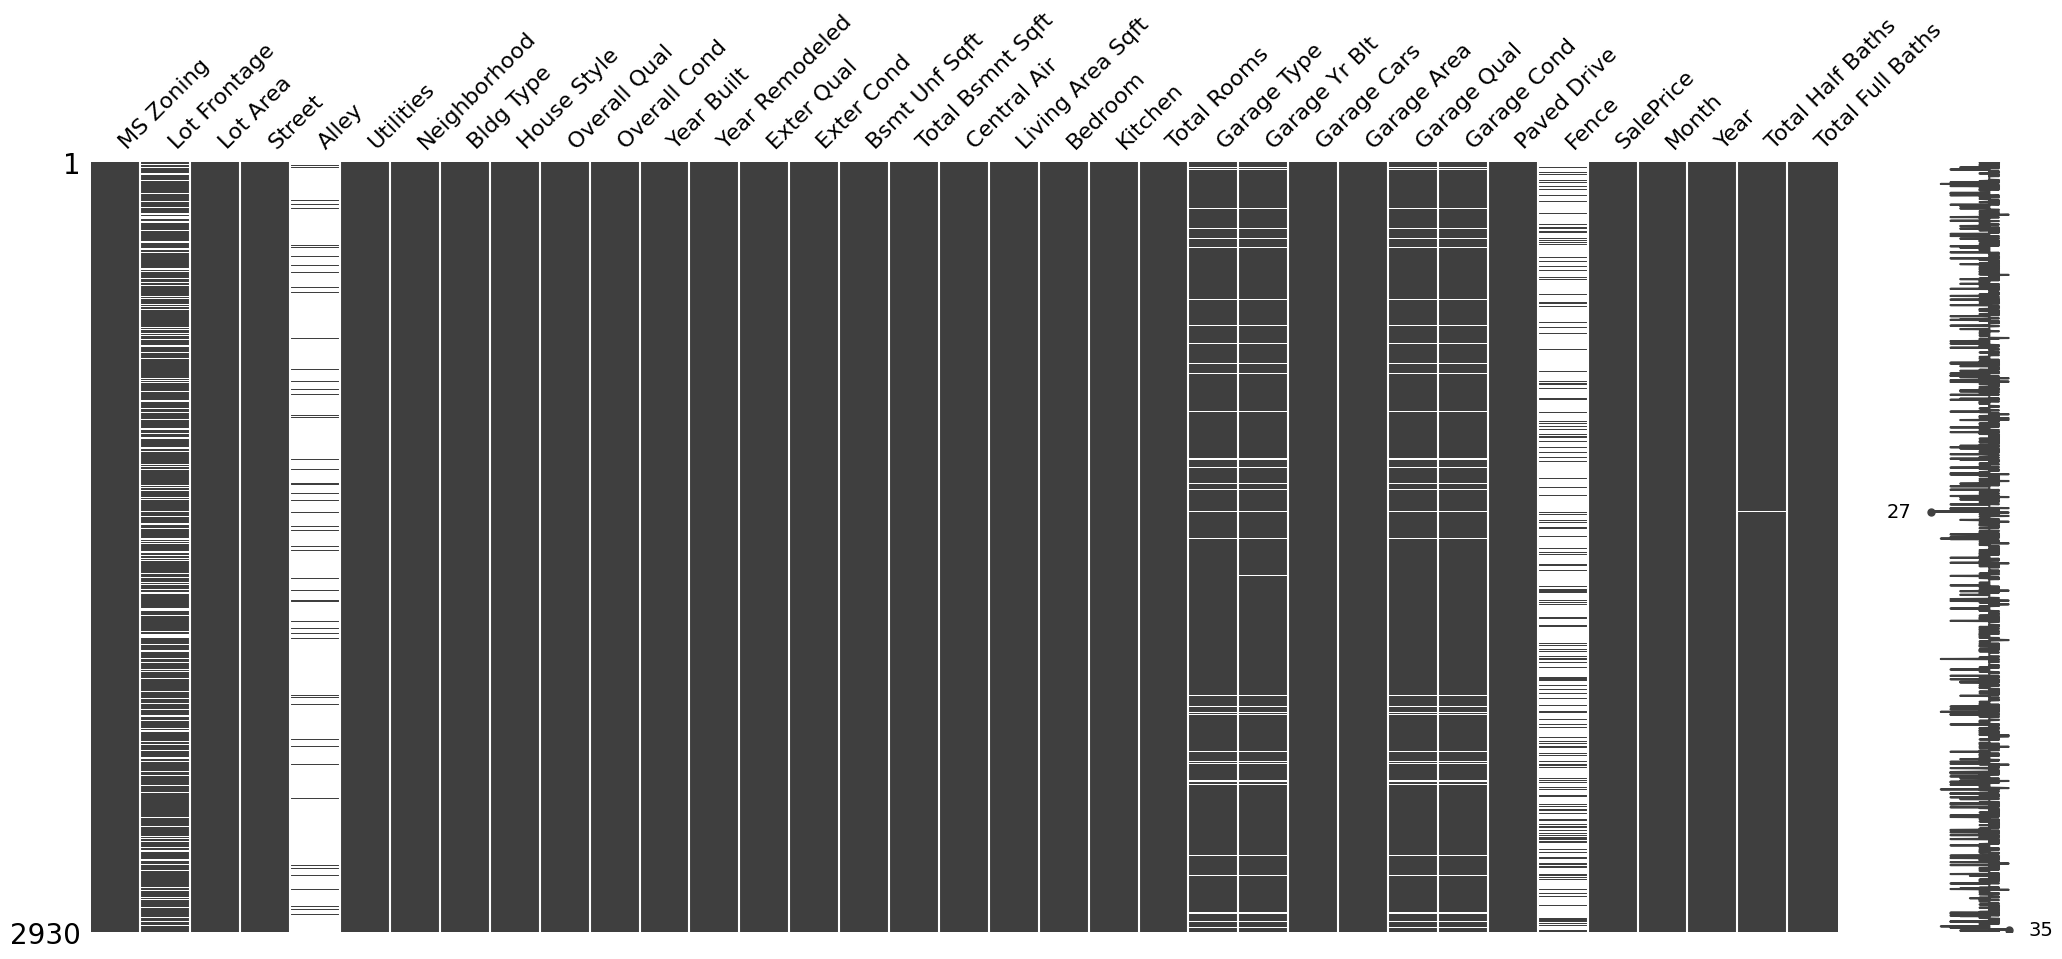

In [ ]:
# Visualize null values
msno.matrix(df);

In [ ]:
# Check for null values
null_count = df.isna().sum()
null_count[ null_count>0]

,0
Lot Frontage,490
Alley,2732
Bsmt Unf Sqft,1
Total Bsmnt Sqft,1
Garage Type,157
Garage Yr Blt,160
Garage Cars,1
Garage Area,1
Garage Qual,159
Garage Cond,159


##**Step 4: Validation Split.**

**Coulumn drop**

1- Utilities

1- Street

**Stakeholder can't change:**

1- MS Zoning

2- Lot Frontage

3- Lot Area

4- Neighborhood

5- Year Built


**Instead of permanently deleting columns from the data:**

**We only delete them when we create the variable X(features).**

**This means the deletion is non-destructive.**

----------------------------------------------------

**This method allows you to easily add or remove columns by modifying a single list.**

**Because model building is an iterative process, you can experiment with different features each time**.

**In short: Flexibility and ease of modification without changing all the code**.


In [ ]:
# Separate features vs target & train/test split
drop_from_model = ['Utilities', "Street",'MS Zoning','Lot Frontage',
                   'Lot Area','Neighborhood','Year Built']
# Demonstrating unpacking list with star operator
[*drop_from_model,'SalePrice']

In [ ]:
# Separate features vs target & train/test split
drop_from_model = ['Utilities', # Quasi-constant
                   "Street", # Quasi-constant
                   'MS Zoning', # Stakeholder can't change
                   'Lot Frontage',  # Stakeholder can't change
                   'Lot Area', # Stakeholder can't change
                   'Neighborhood',  # Stakeholder can't change
                   'Year Built'] # Stakeholder can't change
X = df.drop(columns = [*drop_from_model,'SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
X_train.head()

,Alley,Bldg Type,House Style,Overall Qual,Overall Cond,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Month,Year,Total Half Baths,Total Full Baths
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,
905475520,NaN,1Fam,1Story,4,5,1994,TA,TA,0.0,0.0,N,943.0,3,1,5,Detchd,1958.0,1.0,308.0,TA,TA,N,NaN,8,2007,0.0,1.0
909254010,NaN,1Fam,2Story,7,8,1990,TA,TA,600.0,600.0,Y,1228.0,3,1,6,Detchd,1918.0,1.0,215.0,Fa,TA,Y,MnPrv,5,2009,0.0,1.0
531450090,NaN,1Fam,1Story,6,5,1991,TA,TA,78.0,1278.0,Y,1294.0,3,1,6,Attchd,1991.0,2.0,496.0,TA,TA,Y,GdWo,6,2008,0.0,3.0
903400040,Pave,1Fam,2Story,6,6,1950,TA,TA,764.0,764.0,Y,1824.0,3,1,8,Detchd,1940.0,2.0,520.0,TA,TA,N,GdPrv,7,2007,0.0,1.0
527107130,NaN,1Fam,SLvl,7,5,1997,TA,TA,100.0,384.0,Y,1628.0,3,1,7,BuiltIn,1996.0,2.0,390.0,TA,TA,Y,NaN,6,2009,1.0,2.0


##**Step 4: Preprocess the Data**

In [ ]:
## PREPROCESSING PIPELINE FOR NUMERIC DATA
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
num_pipe = make_pipeline(impute_median, scaler)
#(choose_a_name, pipeline_or_transformer, list_of_columns)
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Overall Qual', 'Overall Cond', 'Year Remodeled', 'Bsmt Unf Sqft',
       'Total Bsmnt Sqft', 'Living Area Sqft', 'Bedroom', 'Kitchen',
       'Total Rooms', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Month',
       'Year', 'Total Half Baths', 'Total Full Baths'],
      dtype='object')


In [ ]:
## PREPROCESSING PIPELINE FOR ORDINAL DATA
# Save list of column names
ord_cols = ['Exter Qual','Exter Cond', 'Garage Qual',"Garage Cond"]
print("Ordinal Columns:", ord_cols)
# Create imputer for ordinal data
impute_na_ord = SimpleImputer(strategy='constant', fill_value='NA')
## Making the OrdinalEncoder
# Specifying order of categories for our  Ordinal Qual/Cond Columms
qual_cond_order = ['NA','Po', 'Fa', 'TA', 'Gd', 'Ex']
# Making the list of order lists for OrdinalEncoder
ordinal_category_orders = [qual_cond_order, qual_cond_order,
                           qual_cond_order, qual_cond_order]
ord_encoder = OrdinalEncoder(categories=ordinal_category_orders)
# Making a final scaler to scale category #'s
scaler_ord = StandardScaler()
## Making an ord_pipe
ord_pipe = make_pipeline(impute_na_ord, ord_encoder, scaler_ord)
## Making an ordinal_tuple for ColumnTransformer
#           (choose_a_name, pipeline_or_transformer, list_of_columns)
ord_tuple = ('ordinal', ord_pipe, ord_cols)

Ordinal Columns: ['Exter Qual', 'Exter Cond', 'Garage Qual', 'Garage Cond']


In [ ]:
## PREPROCESSING PIPELINE FOR ONE-HOT-ENCODED DATA
# Save list of column names
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='constant', fill_value = "NA")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
# Making a ohe_tuple for ColumnTransformer
#           (choose_a_name, pipeline_or_transformer, list_of_columns)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['Alley', 'Bldg Type', 'House Style', 'Central Air', 'Garage Type',
       'Paved Drive', 'Fence'],
      dtype='object')


In [ ]:
# Create the Column Transformer
col_transformer = ColumnTransformer([num_tuple, ord_tuple, ohe_tuple],
                                    verbose_feature_names_out=False)
col_transformer

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Overall Qual', 'Overall Cond', 'Year Remodeled', 'Bsmt Unf Sqft',
       'Total Bsmnt Sqft', 'Living Area Sqft', 'Bedroom', 'Kitchen',
       'Total Rooms', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Month',
       'Year', 'Total Half Baths...
                                 ['Exter Qual', 'Exter Cond', 'Garage Qual',
                                  'Garage Cond']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Alley', 'Bldg Type', 'House Style', 'Central Air', 'Garage Type',
       'Paved Drive', 'Fence'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [ ]:
# fit the column transformer on X_train
col_transformer.fit(X_train)
# Transform X_train and X_test
X_train_tf = col_transformer.transform(X_train)
X_test_tf = col_transformer.transform(X_test)
X_train_tf.head()

,Overall Qual,Overall Cond,Year Remodeled,Bsmt Unf Sqft,Total Bsmnt Sqft,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Yr Blt,Garage Cars,Garage Area,Month,Year,Total Half Baths,Total Full Baths,Exter Qual,Exter Cond,Garage Qual,Garage Cond,Alley_Grvl,Alley_NA,Alley_Pave,Bldg Type_1Fam,Bldg Type_2fmCon,...,House Style_1.5Fin,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Central Air_N,Central Air_Y,Garage Type_2Types,Garage Type_Attchd,Garage Type_Basment,Garage Type_BuiltIn,Garage Type_CarPort,Garage Type_Detchd,Garage Type_NA,Paved Drive_N,Paved Drive_P,Paved Drive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NA
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
905475520,-1.453681,-0.502192,0.472590,-1.282165,-2.329907,-1.086450,0.183403,-0.203499,-0.909803,-0.820130,-0.989438,-0.743628,0.674753,-0.605551,-0.807982,-1.289301,-0.679141,-0.227105,0.282215,0.272525,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
909254010,0.648845,2.193205,0.282376,0.093593,-0.996395,-0.525568,0.183403,-0.203499,-0.275453,-2.455923,-0.989438,-1.169681,-0.439858,0.908844,-0.807982,-1.289301,-0.679141,-0.227105,-1.092567,0.272525,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
531450090,-0.051997,-0.502192,0.329930,-1.103317,0.510475,-0.395679,0.183403,-0.203499,-0.275453,0.529399,0.313016,0.117642,-0.068321,0.151646,-0.807982,1.343221,-0.679141,-0.227105,0.282215,0.272525,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
903400040,-0.051997,0.396274,-1.619758,0.469633,-0.631901,0.647364,0.183403,-0.203499,0.993247,-1.556237,0.313016,0.227591,0.303216,-0.605551,-0.807982,-1.289301,-0.679141,-0.227105,0.282215,0.272525,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
527107130,0.648845,-0.502192,0.615250,-1.052872,-1.476459,0.261635,0.183403,-0.203499,0.358897,0.733873,0.313016,-0.367968,-0.068321,0.908844,1.050800,0.026960,-0.679141,-0.227105,0.282215,0.272525,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


##**Step 5: Instantiate and Fit the Model.**

In [ ]:
from sklearn.linear_model import LinearRegression
# Instantiate model
lin_reg = LinearRegression()
#Fit model
lin_reg.fit(X_train_tf, y_train)

LinearRegression()

##**Step 6: Get Predictions from the Model for Training and Testing Data.**

In [ ]:
#Get predictions for training and test data
y_pred_train = lin_reg.predict(X_train_tf)
y_pred_test = lin_reg.predict(X_test_tf)

##**Step 7: Evaluate the Model Using Regression Metrics**

The main idea:

We want to measure how much the model is wrong between:

Actual values

Predicted values

👉 The difference between them is called a residual error.

🔹 The problem:

If we add the errors directly:

In + and - values,

❌ they will cancel each other out → giving us an incorrect result.

🔹 The solution: MAE

👉 Mean Absolute Error

We take the absolute value of each error (without signs)
Then we calculate the average.

🔹 Example:
+5000 → 5000
-5000 → 5000

Total = 10000
Average = 10000 ÷ 2 = 5000

🔹 Why use it?

✔️ There is no cancellation between errors.
✔️ It reflects the true size of the error.

🔹 The important rule:

👉 The smaller the MAE, the better the model.

##**MAE in Python**

In [ ]:
# Calculating MAE with numpy
train_MAE = np.mean(np.abs(y_pred_train - y_train))
test_MAE = np.mean(np.abs(y_pred_test - y_test))
print(f'Model Training MAE: {train_MAE:,.2f}')
print(f'Model Testing MAE: {test_MAE:,.2f}')

Model Training MAE: 21,158.21
Model Testing MAE: 19,928.76


In [ ]:
# Calculating MAE with sklearn
from sklearn.metrics import mean_absolute_error
train_MAE = mean_absolute_error(y_train, y_pred_train)
test_MAE = mean_absolute_error(y_test, y_pred_test)
print(f'Model Training MAE: {train_MAE:,.2f}')
print(f'Model Testing MAE: {test_MAE:,.2f}')

Model Training MAE: 21,158.21
Model Testing MAE: 19,928.76


True = Correct value from the data (y_train or y_test)

Prediction = What the model predicted (y_pred_train or y_pred_test)

Error = Prediction - True

MAE = Average of absolute values ​​of error → Gives a single number that shows
“how far the model is from the truth”



1️⃣ Calculating the Error

Error 1 = 180,000 - 160,000 = +20,000

Error 2 = 190,000 - 200,000 = -10,000

2️⃣ Absolute Value of Error

|+20,000| = 20,000

|-10,000| = 10,000

3️⃣ Adding the Absolute Values

20,000 + 10,000 = 30,000

4️⃣ Calculating the Average (MAE)

30,000 ÷ 2 = 15,000

✅ This is the MAE

**بالمعدل، النموذج يخطئ بحوالي 15,000 وحدة لكل بيت**

##**Mean Squared Error (MSE)**

🔹 The basic idea of ​​MSE

MSE = Mean Squared Error

Similar to MAE, but instead of taking the absolute value of errors, we square each error.

🔹 Why square errors?

Because large errors have a greater impact.

Example:

Error 100 → 100² = 10,000

Error 50 → 50² = 2,500

A larger error results in a larger squared "penalty."

🔹 Practical result

MSE gives a larger number if there are single large errors, even if the rest of the errors are small.

The smaller the MSE, the more accurate the model.

💡 In summary:

MAE = gives the average error directly, treating each error equally.

MSE = gives greater attention to large errors → motivates us to try to reduce large errors first.


**MAE = يعطي متوسط الخطأ بشكل مباشر، يعامِل كل خطأ بالتساوي**

**MSE = يعطي اهتمام أكبر للأخطاء الكبيرة → يحفزنا نحاول تقليل الأخطاء الكبيرة أولًا**

In [ ]:
# Calculating MSE with numpy
train_MSE = np.mean((y_pred_train - y_train)**2)
test_MSE = np.mean((y_pred_test - y_test)**2)
print(f'Model Training MSE: {train_MSE:,.2f}')
print(f'Model Testing MSE: {test_MSE:,.2f}')

Model Training MSE: 1,151,857,608.08
Model Testing MSE: 850,685,987.08


In [ ]:
# Calculating MSE with sklearn
from sklearn.metrics import mean_squared_error
train_MSE = mean_squared_error(y_train, y_pred_train)
test_MSE = mean_squared_error(y_test, y_pred_test)
print(f'Model Training MSE: {train_MSE:,.2f}')
print(f'Model Testing MSE: {test_MSE:,.2f}')

Model Training MSE: 1,151,857,608.08
Model Testing MSE: 850,685,987.08


1️⃣ Squaring the errors

(20,000)^2 = 400,000,000

(-10,000)^2 = 100,000,000

2️⃣ Adding the squared values

400,000,000 + 100,000,000 = 500,000,000

3️⃣ Calculating the mean (MSE)

500,000,000 ÷ 2 = 250,000,000

✅ MSE = 250,000,000

##**R-Squared (R2, R^2)**

🔹 Advantage of MSE:

It penalizes large errors more → It gives importance to large errors

It rewards a consistent model that doesn't make large mistakes

🔹 Problem: It's difficult to interpret the number

Example: The target is in dollars ($) but the MSE is in dollars² ($²) → It doesn't give a direct sense of "how much the model is wrong in dollars"

🔹 Suggested Solution:

We need a metric that:

Penalizes large errors (like MSE)

Is easy to understand and interpret → Is in the same unit as the original target

💡 This usually leads us to use Root Mean Squared Error (RMSE), which is the square root of the MSE.

🔹 Basic Concept

R² = Coefficient of Determination

This shows how much of the target change the model can explain using all its features.

Example to illustrate:

If R² = 0.80 → The model explains 80% of price changes

R² = 1 → The model is perfect

R² = 0 → The model doesn't explain any change

R² < 0 → There's likely a major problem with the model

🔹 How is it calculated?

We calculate the y_pred prediction

We calculate r = correlation between y_pred and y_true

We square the value of r → This is R²

R² = r²
🔹 Comparison with MAE/MSE

MAE/MSE → The smaller the number, the better

R² → The larger the number, the better

**ما هو: نسبة التغير في الهدف الذي يمكن للنموذج تفسيره**

**الفائدة: يعطي فكرة عن جودة النموذج بالنسبة للتغير الكلي**


**المقارنة مع MAE/MSE**

**MAE / MSE → كلما أصغر الرقم = أفضل**

**R² → كلما أكبر الرقم = أفضل**

**النموذج قدر يفسّر 80% من التغيرات في الهدف باستخدام الخصائص اللي عنده.**

In [ ]:
# Calculating R-Squared
train_r2 = np.corrcoef(y_train, y_pred_train)[0][1]**2
test_r2 = np.corrcoef(y_test, y_pred_test)[0][1]**2
print(f'Model Training R2: {train_r2:.2f}')
print(f'Model Testing R2: {test_r2:.2f}')

Model Training R2: 0.83
Model Testing R2: 0.84


In [ ]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
print(f'Model Training R2: {train_r2:.2f}')
print(f'Model Testing R2: {test_r2:.2f}')


Model Training R2: 0.83
Model Testing R2: 0.83


**MAE / MSE → يقيس قديش النموذج يخطئ (صغر الرقم = أفضل)**

**R² → يقيس قديش النموذج يفسر التغير في الهدف (كبر الرقم = أفضل)**

**MAE → يورّيك قديش النموذج بالغلط بالمعدل، يعني على كل بيت تقريبًا النموذج غلط كم دولار.**

**MSE → نفس MAE بس يعاقب الغلطات الكبيرة أكثر، يعني لو غلط كتير مرة وحدة، الرقم يصير أكبر.**

**RMSE → نفس MSE بس سهل تفهمه لأنه بنفس وحدة الدولار، يعني تقريبًا مثل MAE بس مع وزن أكبر للغلطات الكبيرة.**

**R² → يورّيك قديش النموذج فهم التغيّر بالأسعار، يعني إذا 0.8، معناها النموذج فهم 80% من اختلاف الأسعار بين البيوت.**

**بنفس الوحدة = الرقم واضح وفهمه مباشر بالنسبة للشي اللي بدنا نتوقعه.**

**مش بنفس الوحدة = الرقم كبير أو مربّع ويحتاج تفسير إضافي.**

#**Regression Evaluation Functions**

In [ ]:
# Define y_true and y_pred for the test data
y_true = y_test
y_pred = y_pred_test
# Provide a label for this data
label = 'Test Data'

#**Calculate MAE, MSE, RMSE, and R^2**

MAE → يورّيك بالمعدل قديش النموذج يخطئ، يعني على كل بيت تقريبًا النموذج غلط كم دولار.

MSE → نفس MAE بس الأخطاء الكبيرة تعطي “عقوبة” أكبر لأنها مربعة، الرقم صعب تفسيره مباشرة لأنه بالدولار².

RMSE → نفس MSE لكن أخذنا الجذر التربيعي، الرقم صار بالدولار مباشرة وسهل نفهمه كحجم الخطأ.

R² → يورّيك قديش النموذج فاهم التغيرات في الأسعار، مثلاً 0.8 يعني النموذج يفسر 80% من اختلاف الأسعار.

In [ ]:

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE
mae = mean_absolute_error(y_true, y_pred)

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE (الجذر التربيعي لـ MSE)
rmse = np.sqrt(mse)

# R²
r_squared = r2_score(y_true, y_pred)



#**Print Statements**

In [ ]:
# Print the results with f-strings
print(f"Regression Metrics: {label}")
print(f"- MAE = {mae:,.3f}")
print(f"- MSE = {mse:,.3f}")
print(f"- RMSE = {rmse:,.3f}")
print(f"- R^2 = {r_squared:,.3f}")

Regression Metrics: Test Data
- MAE = 19,928.762
- MSE = 850,685,987.084
- RMSE = 29,166.522
- R^2 = 0.826


**MAE = 19,928.76**

→ بالمعدل، النموذج بالغلط حوالي 20 ألف دولار لكل بيت على بيانات الاختبار.

→ هذا يوضح حجم الخطأ المتوسط بدون النظر للاتجاه (إذا توقع أعلى أو أقل).

**MSE = 850,685,987.08**

→ متوسط مربعات الأخطاء. الرقم كبير لأنه مربّع الدولار، يعني الأخطاء الكبيرة تأخذ وزن أكبر.

→ يعطي “عقوبة أكبر للغلطات الكبيرة” لكنه صعب نفهمه مباشرة بالدولار.

**RMSE = 29,166.52**

→ الجذر التربيعي للـ MSE، صار بالدولار مباشرة.

→ معناته النموذج غالبًا يغلط حوالي 29 ألف دولار لكل بيت على بيانات الاختبار، والأخطاء الكبيرة تؤثر أكثر من المتوسط العادي.

**R² = 0.826**

→ يعني النموذج يفسر 82.6% من التغيرات في أسعار البيوت.

→ النموذج فاهم معظم الاختلافات بين الأسعار، والباقي حوالي 17% أسباب ما دخلت بالبيانات أو عشوائية

In [ ]:
# Define a header with 60 dashes
header = "-"*60
# Preview the results
print(header)

------------------------------------------------------------


In [ ]:
# Print the title with the header lines
print(header, f"Regression Metrics: {label}", header, sep= '\n')

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------


In [ ]:
# Print the results with f-strings
print(header, f"Regression Metrics: {label}", header, sep= '\n')
print(f"- MAE = {mae:,.3f}")
print(f"- MSE = {mse:,.3f}")
print(f"- RMSE = {rmse:,.3f}")
print(f"- R^2 = {r_squared:,.3f}")

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 19,928.762
- MSE = 850,685,987.084
- RMSE = 29,166.522
- R^2 = 0.826


##**Save Results as Dictionary**

In [ ]:
# We can store the label and each metric in a dictionary
metrics = {'Label':label, 'MAE':mae,'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}

In [ ]:
# Now that we have the dictionary, we call retrieve any of the values by using the key.
metrics['MAE']

19928.762487233875

##**Define the Function**

In [ ]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

##**Test the Function**

In [ ]:
# Test function using test data and default for output_dict
regression_metrics(y_test, y_pred_test, label = 'Test Data')

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 19,928.762
- MSE = 850,685,987.084
- RMSE = 850,685,987.084
- R^2 = 0.826


In [ ]:
# Test function on training data and save the dictionary as a variable
training_metrics = regression_metrics(y_train, y_pred_train, label = 'Training Data', output_dict = True)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 21,158.209
- MSE = 1,151,857,608.078
- RMSE = 1,151,857,608.078
- R^2 = 0.832


In [ ]:
# Confirm dictionary
training_metrics

{'Label': 'Training Data',
 'MAE': 21158.20898838255,
 'MSE': 1151857608.0778334,
 'RMSE': 1151857608.0778334,
 'R^2': 0.8323968935713407}

##**Custom Function: evalute_regression**

##**Define the Function**

In [ ]:
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  # التنبؤ على بيانات التدريب
  y_train_pred = reg.predict(X_train)


  # يستدعي دالة regression_metrics ليحسب MAE, MSE, RMSE, R² على بيانات التدريب.
  #إذا verbose=True → يطبع النتائج مباشرة.
  #إذا output_frame=True → يرجع النتائج كـ dictionary أو dataframe لاحقًا.
  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  #نفس الفكرة، لكن على بيانات الاختبار للتأكد من أداء النموذج على بيانات جديدة.
  y_test_pred = reg.predict(X_test)

  #يحسب MAE, MSE, RMSE, R² على بيانات الاختبار.
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  #تحويل النتائج إلى DataFrame (اختياري)
  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

#**Test the Function**

In [ ]:
 # Test function with default arguments
evaluate_regression(lin_reg, X_train_tf, y_train, X_test_tf, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 21,158.209
- MSE = 1,151,857,608.078
- RMSE = 1,151,857,608.078
- R^2 = 0.832

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 19,928.762
- MSE = 850,685,987.084
- RMSE = 850,685,987.084
- R^2 = 0.826


In [ ]:
# Test function by saving results as a datframe
results_df = evaluate_regression(lin_reg, X_train_tf, y_train, X_test_tf, y_test,
                              output_frame=True)
results_df

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 21,158.209
- MSE = 1,151,857,608.078
- RMSE = 1,151,857,608.078
- R^2 = 0.832

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 19,928.762
- MSE = 850,685,987.084
- RMSE = 850,685,987.084
- R^2 = 0.826


,MAE,MSE,RMSE,R^2
Training Data,21158.209,1.151858e+09,1.151858e+09,0.832
Test Data,19928.762,8.506860e+08,8.506860e+08,0.826


In [ ]:
# Test function by saving results as a dataframe and suppressing print statements with verbose = False
results = evaluate_regression(lin_reg, X_train_tf, y_train, X_test_tf, y_test, verbose = False, output_frame = True)

**verbose=True** → تطبع النتائج على الشاشة.

**verbose=False** → تحسب النتائج بس بدون طباعة، مفيد للحلقات أو الاستخدام المتكرر.

In [ ]:
# View the dataframe
results

,MAE,MSE,RMSE,R^2
Training Data,21158.209,1.151858e+09,1.151858e+09,0.832
Test Data,19928.762,8.506860e+08,8.506860e+08,0.826


الـ MAE و MSE و RMSE (مقاييس الخطأ)

هدول الأعمدة الثلاثة وظيفتهم واحدة: يجاوبوا على سؤال "كم الموديل غلطان؟".

التفسير: الموديل بيقدر يفسر حوالي 83% من الأسباب اللي بتغير السعر (أو الطول). هاد الرقم عالي جداً وممتاز لموديل Linear Regression.

الفرق بين الصفين (لماذا نقارن؟)

إحنا بنقارن الصفين عشان نتأكد من شغلة اسمها Generalization (القدرة على التعميم):

بما إن الأرقام في الـ Test قريبة جداً من الـ Training، معناه الموديل عندك متوازن.